In [93]:
import IPython.display
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.io import wavfile
from scipy import signal
from pathlib import Path

DATA_22 = Path(r"C:\Users\HP\Desktop\Skripsie data\DataSubmission\2023_04_22")
plt.rcParams['figure.figsize'] = [10, 5]

In [94]:
#store start and end times in array
df = pd.read_csv(DATA_22 / "20230422_171301.Detections.selections.txt", sep="\t") #tabs are used to seperate columns"
print("number of calls detected: ", len(df))

diff = np.zeros(len(df))
for i in range(len(df)):
    diff[i] = df["End Time (s)"][i] - df["Begin Time (s)"][i]
average_call_length = np.mean(diff)
longest_call_length = np.max(diff)
shortest_call_length = np.min(diff)

print("Average call length: ", average_call_length)
print("Longest call length: ", longest_call_length)
print("Shortest call length: ", shortest_call_length)

number of calls detected:  1262
Average call length:  0.23144205626084713
Longest call length:  2.4559374999953434
Shortest call length:  0.09599999999045394


In [95]:
#Clip wanted audio segment from the original audio file
pad = 0.1
start_t = df["Begin Time (s)"].values - pad
end_t = df["End Time (s)"].values + pad

fn = DATA_22 / "20230422_171301.WAV"
f_s, x = wavfile.read(fn)
print("Sampling frequency: ", f_s)

call_no = 1
start_sample = int(start_t[call_no] * f_s)
end_sample = int(end_t[call_no] * f_s)

audio_segment = x[start_sample:end_sample]

IPython.display.Audio(audio_segment, rate=f_s)

Sampling frequency:  8000


In [ ]:
#Calculate the STFT of the audio segment
fs_new = 2000
up = 1
down = int(f_s / fs_new)
audio_resampled = signal.resample_poly(audio_segment, up, down)

framelength = 256
noverlap = int(framelength * 0.8)
window = "hamming"
f, t, fft_frames = signal.stft(audio_resampled, fs_new, nperseg=framelength, noverlap=noverlap, window=window)
print("Number of frequency bins: ", len(f))

Number of frequency bins:  129


(0.0, 1000.0)

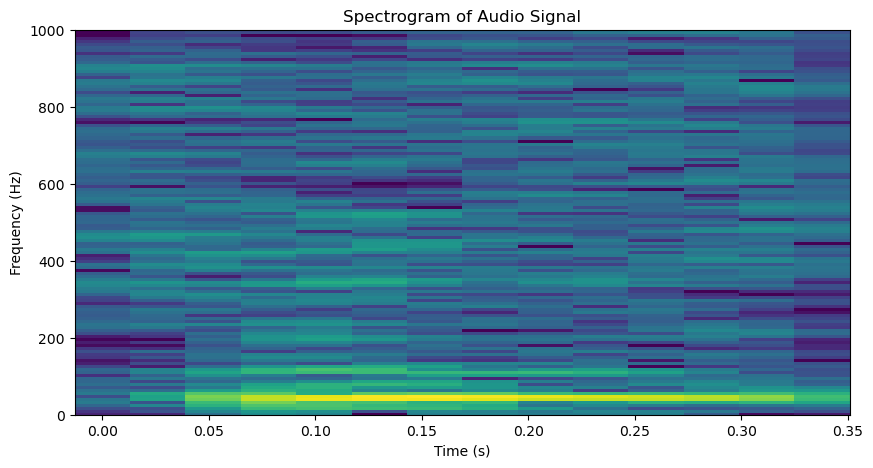

In [97]:
#Plot the spectrogram of the audio segment
plt.pcolormesh(t, f, np.log(np.abs(fft_frames + 1e-16)), vmin = 0, vmax = np.max(np.log(np.abs(fft_frames + 1e-16))));
plt.xlabel("Time (s)")
plt.ylabel("Frequency (Hz)")
plt.title("Spectrogram of Audio Signal")
plt.ylim(0, fs_new/2)